##**Business Scenario**
**A large e-commerce company receives thousands of product reviews every day.
Management wants an AI system that can automatically detect whether a review is positive or negative, so they can:
Highlight positive reviews
Detect negative customer experiences early
Improve product quality
You are hired as a Data Scientist to build a Deep Learning model using Recurrent Neural Networks (RNN) to analyze the review text and predict sentiment.**


Column	Description

review	Text review

sentiment	positive / negative



###**Task 1 — Understand the Business Problem**

You must first analyze the problem before coding.

Tasks:
- Explain why text reviews are sequential data
- Explain why traditional ML models struggle with sequence understanding
- Justify why RNN is suitable for this problem

Expected explanation should include:

- order of words matters
- contextual meaning
- sequential memory

###**Task 2 — Data Exploration**

Students should explore the dataset.

Tasks:
- Load the dataset
- Check dataset size
- Count positive vs negative reviews
- Display sample reviews
- Calculate average review length

Check:

- Are reviews balanced?
- Are reviews long or short?

###**Task 3 — Text Preprocessing**

Raw text cannot be fed directly into neural networks.
You must perform preprocessing:

Tasks:

- Convert text to lowercase
- Remove punctuation
- Remove HTML tags
- Tokenize words
- Remove stopwords
- Convert words → sequences
- Expected output example:

Original:

    "This movie was absolutely fantastic!"
    Processed:
    ["movie", "absolutely", "fantastic"]

###**Task 4 — Tokenization and Vocabulary Building**

You must convert words into numerical representations.

Tasks:

- Use Keras Tokenizer
- Create vocabulary
- Convert reviews → sequences
- Display word index mapping

Example:

Word	Index

movie	1

good	2

bad	3

Check:

- Why neural networks cannot process raw text directly?



###**Task 5 — Sequence Padding**

RNN requires fixed-length input sequences.

Tasks:

- Find maximum review length
- Apply padding using pad_sequences()
- Compare before and after padding

Example:

    Before padding
    [12, 45, 67]
    After padding
    [0,0,0,12,45,67]

You must explain:

- Why padding is necessary for RNN models.

###**Task 6 — Build an RNN Model**

You must implement a simple RNN architecture.

Architecture example:

    Embedding Layer
    SimpleRNN Layer
    Dense Layer
    Output Layer

Tasks:

- Define embedding layer
- Add SimpleRNN layer
- Add dense output layer
- Compile model

Students must print:
- model.summary()


###**Task 7 — Train the RNN Model**

You must train the model.

Tasks:

- Split dataset into train/test
- Train the RNN model
- Plot training accuracy
- Plot validation accuracy

You must analyze:

- Is the model overfitting?
- Is accuracy improving?


###**Task 8 — Evaluate Model Performance**

You must evaluate the trained model.

Tasks:

- Calculate accuracy
- Generate confusion matrix
- Compute precision and recall
- Analyze misclassified reviews

You must interpret:

- Which type of reviews are harder to classify?

###**Task 9 — Real-Time Prediction System**


You must build a custom review prediction function.

Example:

Input:
    "This product quality is amazing"
Expected Output:

    Predicted Sentiment → Positive
    Confidence → 0.92
You must test at least 5 custom reviews.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


In [ ]:
#Load Dataset
df = pd.read_csv('../DataSets/IMDB_Dataset.csv')  # change path if needed

df.head()

Mounted at /content/drive


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#**TASK - 2 : Data Exploration**

In [ ]:
# 2. Dataset Size
print("Dataset Shape:", df.shape)

print("\nSentiment Count:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:\n")
for i in range(3):
    print(f"Review {i+1}:")
    print(df['review'][i])
    print("Sentiment:", df['sentiment'][i])
    print("-" * 80)

df['length'] = df['review'].apply(lambda x: len(x.split()))

print("\nAverage Review Length:", df['length'].mean())

print("\nMin Length:", df['length'].min())
print("Max Length:", df['length'].max())

Dataset Shape: (50000, 2)

Sentiment Count:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuf

#**TASK -3 : Text Processing**

In [ ]:


import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return words

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Show example
print("\nOriginal Review:")
print(df['review'][0])

print("\nProcessed Review:")
print(df['cleaned_review'][0])



# Convert list back to sentence
df['cleaned_review_str'] = df['cleaned_review'].apply(lambda x: " ".join(x))

# Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['cleaned_review_str'])

# Convert to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_review_str'])

# Padding
X = pad_sequences(sequences, maxlen=100)

# Encode labels
y = df['sentiment'].map({'positive':1, 'negative':0})

print("Sample sequence:", sequences[0])
print("Padded shape:", X.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

#**Task 4 — Tokenization and Vocabulary Building**

In [ ]:


# Initialize tokenizer
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")

# Fit on cleaned text
tokenizer.fit_on_texts(df['cleaned_review_str'])

# Create vocabulary (word index)
word_index = tokenizer.word_index

print("Total Vocabulary Size:", len(word_index))

# Display first 10 words
print("\nSample Word Index Mapping:")
for word, index in list(word_index.items())[:10]:
    print(f"{word} : {index}")

# Convert text → sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_review_str'])

print("\nSample Review:")
print(df['cleaned_review_str'][0])

print("\nConverted Sequence:")
print(sequences[0])

Total Vocabulary Size: 214479

Sample Word Index Mapping:
<OOV> : 1
movie : 2
film : 3
one : 4
like : 5
good : 6
even : 7
would : 8
time : 9
really : 10

Sample Review:
one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched deve

#**Task 5 — Sequence Padding**

In [ ]:


max_length = max(len(seq) for seq in sequences)
print("Maximum Review Length:", max_length)


print("\nBefore Padding:")
print(sequences[0])


X = pad_sequences(sequences, maxlen=max_length, padding='pre')

print("\nAfter Padding:")
print(X[0])


print("\nPadded Data Shape:", X.shape)

Maximum Review Length: 1420

Before Padding:
[4, 1792, 933, 57, 3148, 283, 348, 2992, 108, 478, 468, 1, 20, 58, 3066, 3148, 1, 1, 51, 469, 181, 108, 545, 53, 1588, 42, 1, 1, 1, 42, 2334, 1, 1, 1326, 275, 469, 3224, 245, 235, 1, 352, 3148, 1, 240, 1, 1, 2392, 930, 1, 2458, 1233, 1, 418, 4498, 2351, 1068, 1, 2794, 1, 297, 1, 1, 213, 4835, 3495, 418, 237, 1, 1, 1, 1, 4926, 1, 2290, 1, 1, 223, 1, 1, 1, 1, 1, 35, 127, 1, 8, 46, 167, 1157, 42, 547, 92, 160, 155, 433, 2816, 699, 85, 1130, 4117, 2330, 967, 699, 1271, 699, 1, 59, 846, 88, 20, 283, 44, 105, 3066, 1433, 2048, 286, 46, 1408, 176, 1323, 1108, 3148, 89, 1, 213, 1929, 1941, 469, 469, 1, 1, 4719, 1, 2772, 1, 1, 1, 377, 497, 15, 141, 14, 1, 627, 689, 1, 539, 1068, 1, 547, 437, 802, 1844, 1068, 440, 57, 3148, 99, 301, 3559, 3083, 1, 15, 1072, 3814, 389]

After Padding:
[   0    0    0 ... 1072 3814  389]

Padded Data Shape: (50000, 1420)


#**TASK-6 : Build a RNN Model**

In [ ]:
# RNN model

v = len(word_index) + 1

m = Sequential()
m.add(Embedding(v, 64, input_length=max_length))
m.add(SimpleRNN(64))
m.add(Dense(32, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

m.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##**Task 7 — Train the RNN Model**


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 106ms/step - accuracy: 0.5988 - loss: 0.6475 - val_accuracy: 0.6810 - val_loss: 0.5815
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 98ms/step - accuracy: 0.7807 - loss: 0.4620 - val_accuracy: 0.8312 - val_loss: 0.3872
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 98ms/step - accuracy: 0.8220 - loss: 0.3965 - val_accuracy: 0.8353 - val_loss: 0.3974
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.8728 - loss: 0.3100 - val_accuracy: 0.8436 - val_loss: 0.4301
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 98ms/step - accuracy: 0.8386 - loss: 0.3698 - val_accuracy: 0.8176 - val_loss: 0.4253


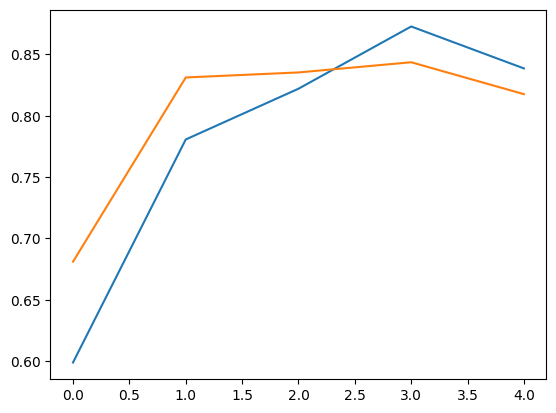

In [ ]:
# training
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

h = m.fit(xtr, ytr, epochs=5, batch_size=32, validation_data=(xte, yte))

plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.show()

###**Task 8: Model Evaluation**

In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix, precision_score, recall_score

yp = (m.predict(xte) > 0.5).astype("int32")

acc = m.evaluate(xte, yte)[1]
cm = confusion_matrix(yte, yp)
p = precision_score(yte, yp)
r = recall_score(yte, yp)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Precision:", p)
print("Recall:", r)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8176 - loss: 0.4253
Accuracy: 0.8176000118255615
Confusion Matrix:
 [[3669 1292]
 [ 532 4507]]
Precision: 0.7772029660286256
Recall: 0.8944234967255408


###**Task 9: Real-Time Prediction**

In [ ]:
# prediction
def f(t):
    t = t.lower()
    t = re.sub(r'<.*?>', '', t)
    t = re.sub(r'[^a-zA-Z\s]', '', t)
    w = [i for i in t.split() if i not in stop_words]
    s = tokenizer.texts_to_sequences([" ".join(w)])
    s = pad_sequences(s, maxlen=max_length)
    p = m.predict(s)[0][0]
    return ("Positive" if p>0.5 else "Negative", float(p))

In [ ]:
# test
tests = [
    "This product quality is amazing"
]

for t in tests:
    print(t, "→", f(t))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
This product quality is amazing → ('Positive', 0.9994989633560181)
